In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
os.chdir('/home/seunghan.lee/workspace/cross-rag/viz_result')

In [2]:
os.listdir()

['exchange_rate_zeroshot_512_pred_64_512_retrieve_64_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7',
 'ETTh1_zeroshot_512_pred_64_512_retrieve_64_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7',
 'ETTh2_zeroshot_512_pred_64_512_retrieve_64_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7',
 'ETTm1_zeroshot_512_pred_64_512_retrieve_64_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7',
 'ETTm2_zeroshot_512_pred_64_512_retrieve_64_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7',
 'weather_zeroshot_512_pred_64_512_retrieve_64_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7',
 'exchange_rate_zeroshot_512_pred_64_512_retrieve_64_Z_k5',
 'ETTh1_zeroshot_512_pred_64_512_retrieve_64_Z_k5',
 'ETTh2_zeroshot_512_pred_64_512_retrieve_64_Z_k5',
 '.ipynb_checkpoints',
 'ETTm1_zeroshot_512_pred_64_512_retrieve_64_Z_k5',
 'electricity_zeroshot_512_pred_64_512_retrieve_64_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7',
 'ETTm2_zeroshot_512_pred_64_512_retrieve_64_Z_k5',
 'weather_zeroshot_512_pred_

In [8]:
index_dict = dict()
dataset = 'exchange' # 7558,7511,3227,8037,9379,9081,8141,7507,7549,7514,7538,9384,7561,10203,5390
index_dict[dataset] = sorted([3227,8037,9379,9081,7549,7538,10203,5390])

dataset = 'ETTh1' # 18809,18773,17263,17532,17028,18810,
index_dict[dataset] = sorted([18809,18773,17263,17532,17028,18810])
dataset = 'ETTh2' # 3944, 13883,13881, 19033
index_dict[dataset] = sorted([3944, 13883,13881, 19033, 3946,13889,])
dataset = 'ETTm2' # 7468, 7469, 7470, 3743, 7488, 7478, 52802, 7474, 18200, 521712, 54527, 52809,7472
index_dict[dataset] = sorted([43742,43079,78207,15750,43051,75688,19724,9368,74083,9864,42989,38593])
dataset = 'ETTm1' # 7488, 7478, 52802,52804,7474,7472,52809,7469,52712,18200,
index_dict[dataset] = sorted([7488, 52804,7474,52712,18200,])
dataset = 'weather' # 126968, 46872,44710,44711,44716,170157,23802,13327,107715,175923,21038,55226,21039,21040,21041, 107710,23669,126410,
index_dict[dataset] = sorted([126968, 46872,44710,170157,23802,13327,175923,21038,55226, 107710,23669,126410,])
dataset = 'electricity' # 544093,666981,666964,33062,33058, 666963,33050,33051,33067,33082,666969,131954,131953,544091,
index_dict[dataset] = sorted([666981, 666963,33051,33082,131954,544091,])

fns = [x for x in os.listdir() if dataset in x]

In [9]:
dataset = 'ETTh2'
fns = [x for x in os.listdir() if dataset in x]
fn_base = [x for x in fns if 'dualhead' not in x][0]
fn_ours = [x for x in fns if 'dualhead' in x][0]

X = np.load(os.path.join(fn_base,'input.npy'))[0]
Y_gt = np.load(os.path.join(fn_base,'ground_truth.npy'))[0]
Y_pred_base = np.load(os.path.join(fn_base,'output.npy'))[0]
Y_pred_ours = np.load(os.path.join(fn_ours,'output.npy'))[0]

In [10]:
# # Calculate MAE
# mae_base = np.mean(np.abs(Y_pred_base - Y_gt), axis=1)
# mae_ours = np.mean(np.abs(Y_pred_ours - Y_gt), axis=1)

# # Y_pred_ours는 잘 예측했지만 (낮은 MAE), Y_pred_base는 잘 예측하지 못한 (높은 MAE) 샘플 찾기
# # calculate difference: base의 MAE가 높고 ours의 MAE가 낮을수록 좋은 후보
# diff_mae = mae_base - mae_ours

# # Select TopK (default value: 10개)
# topk = 1000
# topk_indices = np.argsort(diff_mae)[-topk:][::-1]  # sort by largest difference

# # print(f"Top {topk} samples where ours performed well but base did not:")
# # print(f"Sample indices: {topk_indices}")
# # print(f"\nMAE differences (base - ours):")
# # for idx in topk_indices:
# #     print(f"  Sample {idx}: base_mae={mae_base[idx]:.4f}, ours_mae={mae_ours[idx]:.4f}, diff={diff_mae[idx]:.4f}")

# # visualization
# for i, sample_idx in enumerate(topk_indices[300:400]):
#     plt.figure(figsize=(12, 6))
#     plt.plot(np.arange(512), X[sample_idx], 'k-', alpha=0.5, label='input')
#     plt.plot(np.arange(512, 512+64), Y_gt[sample_idx], 'g-', linewidth=2, label='gt')
#     plt.plot(np.arange(512, 512+64), Y_pred_base[sample_idx], 'r--', linewidth=2, label=f'base pred (MAE={mae_base[sample_idx]:.4f})')
#     plt.plot(np.arange(512, 512+64), Y_pred_ours[sample_idx], 'b--', linewidth=2, label=f'ours pred (MAE={mae_ours[sample_idx]:.4f})')
#     plt.axvline(x=512, color='gray', linestyle=':', alpha=0.5)
#     plt.xlabel('Time step')
#     plt.ylabel('Value')
#     plt.title(f'Sample {sample_idx} (Rank {i+1}, MAE diff={diff_mae[sample_idx]:.4f})')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

In [11]:
# # Calculate MAE
# fn_base = [x for x in fns if 'dualhead' not in x][0]
# fn_ours = [x for x in fns if 'dualhead' in x][0]

# X = np.load(os.path.join(fn_base,'input.npy'))[0]
# Y_gt = np.load(os.path.join(fn_base,'ground_truth.npy'))[0]
# Y_pred_base = np.load(os.path.join(fn_base,'output.npy'))[0]
# Y_pred_ours = np.load(os.path.join(fn_ours,'output.npy'))[0]

# mae_base = np.mean(np.abs(Y_pred_base - Y_gt), axis=1)
# mae_ours = np.mean(np.abs(Y_pred_ours - Y_gt), axis=1)

# # Y_pred_ours는 잘 예측했지만 (낮은 MAE), Y_pred_base는 잘 예측하지 못한 (높은 MAE) 샘플 찾기
# # calculate difference: base의 MAE가 높고 ours의 MAE가 낮을수록 좋은 후보
# diff_mae = mae_base - mae_ours

# # Select TopK (default value: 10개)
# topk = 1000
# topk_indices = np.argsort(diff_mae)[-topk:][::-1]  # sort by largest difference

# # print(f"Top {topk} samples where ours performed well but base did not:")
# # print(f"Sample indices: {topk_indices}")
# # print(f"\nMAE differences (base - ours):")
# # for idx in topk_indices:
# #     print(f"  Sample {idx}: base_mae={mae_base[idx]:.4f}, ours_mae={mae_ours[idx]:.4f}, diff={diff_mae[idx]:.4f}")

# # visualization
# for i, sample_idx in enumerate(topk_indices[200:300]):
#     plt.figure(figsize=(12, 6))
#     plt.plot(np.arange(512), X[sample_idx], 'k-', alpha=0.5, label='input')
#     plt.plot(np.arange(512, 512+64), Y_gt[sample_idx], 'g-', linewidth=2, label='gt')
#     plt.plot(np.arange(512, 512+64), Y_pred_base[sample_idx], 'r--', linewidth=2, label=f'base pred (MAE={mae_base[sample_idx]:.4f})')
#     plt.plot(np.arange(512, 512+64), Y_pred_ours[sample_idx], 'b--', linewidth=2, label=f'ours pred (MAE={mae_ours[sample_idx]:.4f})')
#     plt.axvline(x=512, color='gray', linestyle=':', alpha=0.5)
#     plt.xlabel('Time step')
#     plt.ylabel('Value')
#     plt.title(f'Sample {sample_idx} (Rank {i+1}, MAE diff={diff_mae[sample_idx]:.4f})')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

In [12]:
# dataset = 'exchange' 
#dataset = 'ETTh1' # 18809,18773,17263,17532,17028,18810,
dataset = 'ETTh2' # 3944, 13883,13881, 19033
#dataset = 'ETTm1' # 7468, 7469, 7470, 3743, 7488, 7478, 52802, 7474, 18200, 521712, 54527, 52809,7472
#dataset = 'ETTm2' # 7488, 7478, 52802,52804,7474,7472,52809,7469,52712,18200,
#dataset = 'weather' # 126968, 46872,44710,44711,44716,170157,23802,13327,107715,175923,21038,55226,21039,21040,21041, 107710,23669,126410,
# dataset = 'electricity' # 544093,666981,666964,33062,33058, 666963,33050,33051,33067,33082,666969,131954,131953,544091,

index_list = index_dict[dataset]
fns = [x for x in os.listdir() if dataset in x]

# Calculate MAE
fn_base = [x for x in fns if 'dualhead' not in x][0]
fn_ours = [x for x in fns if 'dualhead' in x][0]

X = np.load(os.path.join(fn_base,'input.npy'))[0]
Y_gt = np.load(os.path.join(fn_base,'ground_truth.npy'))[0]
Y_pred_base = np.load(os.path.join(fn_base,'output.npy'))[0]
Y_pred_ours = np.load(os.path.join(fn_ours,'output.npy'))[0]

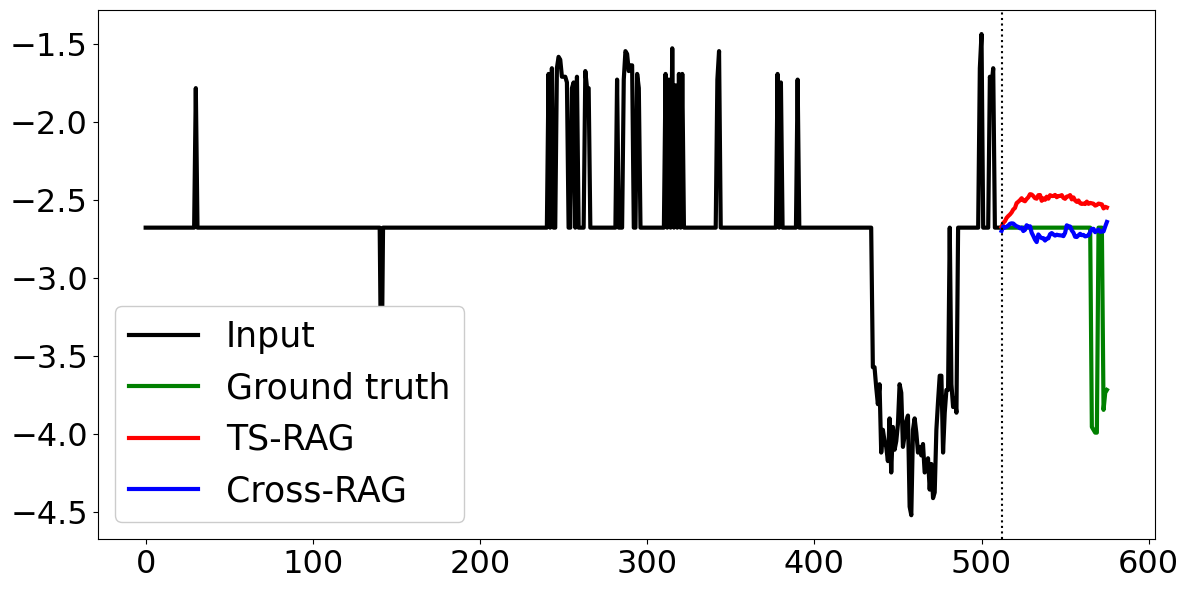

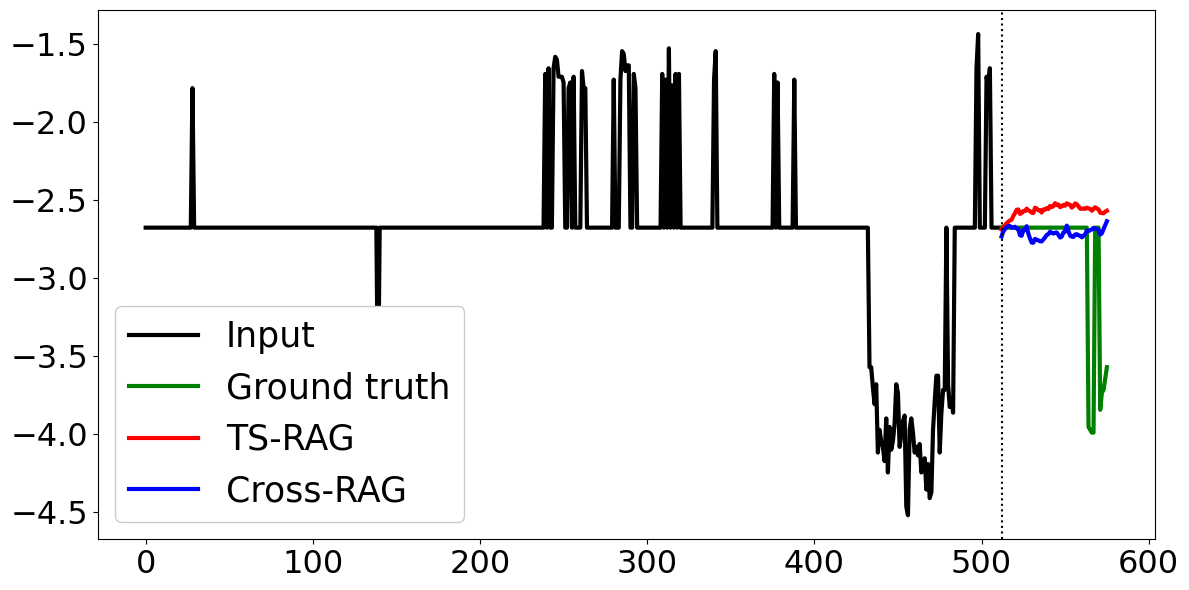

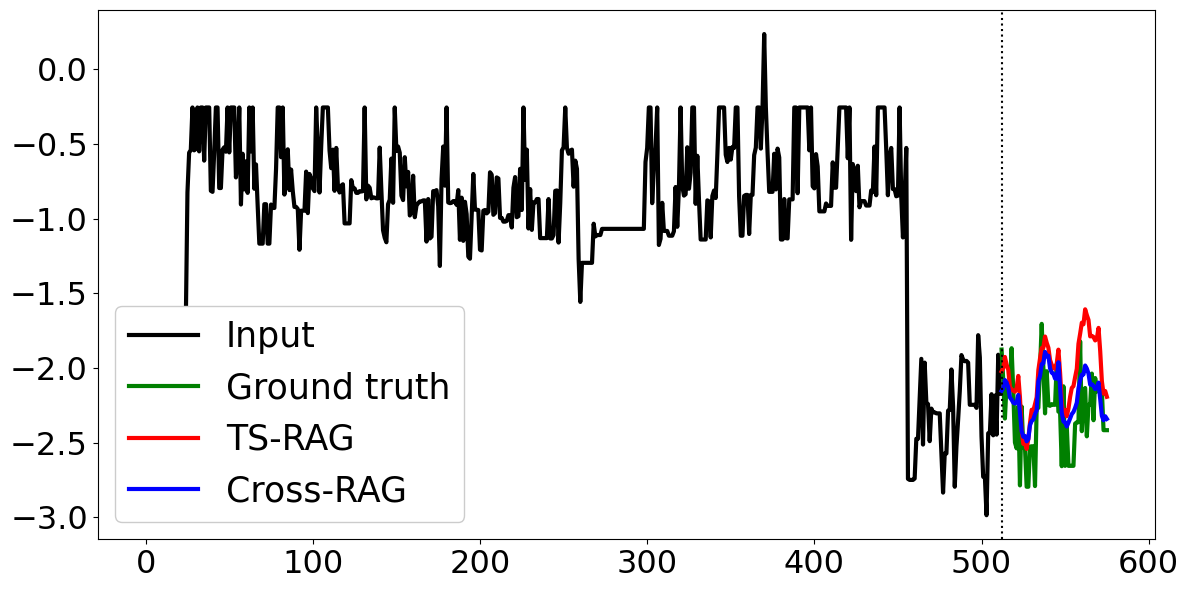

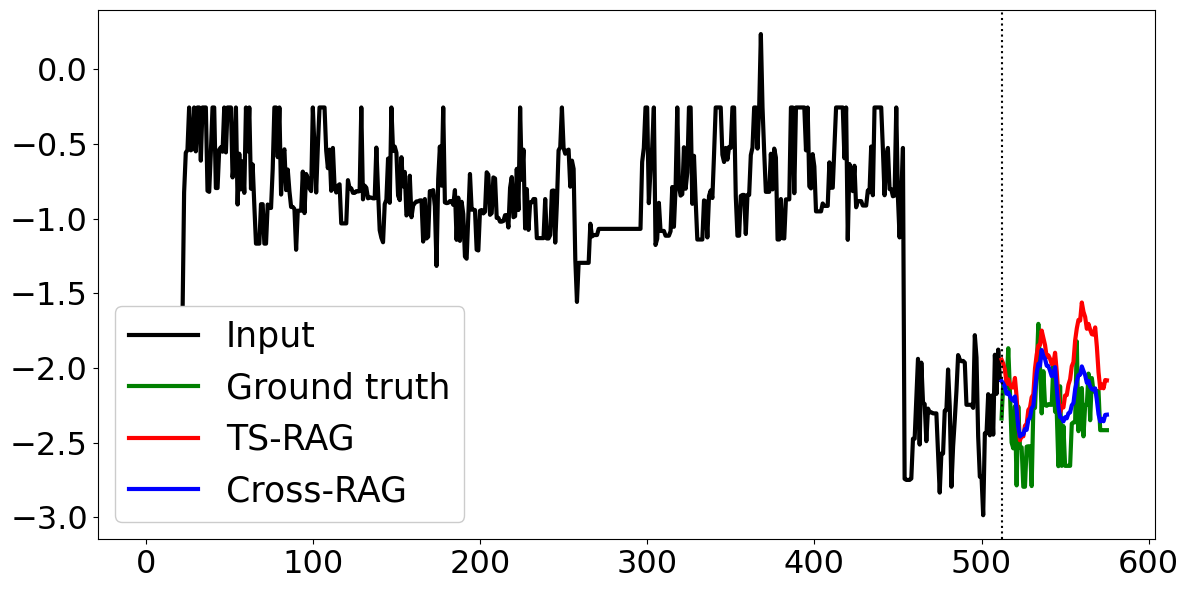

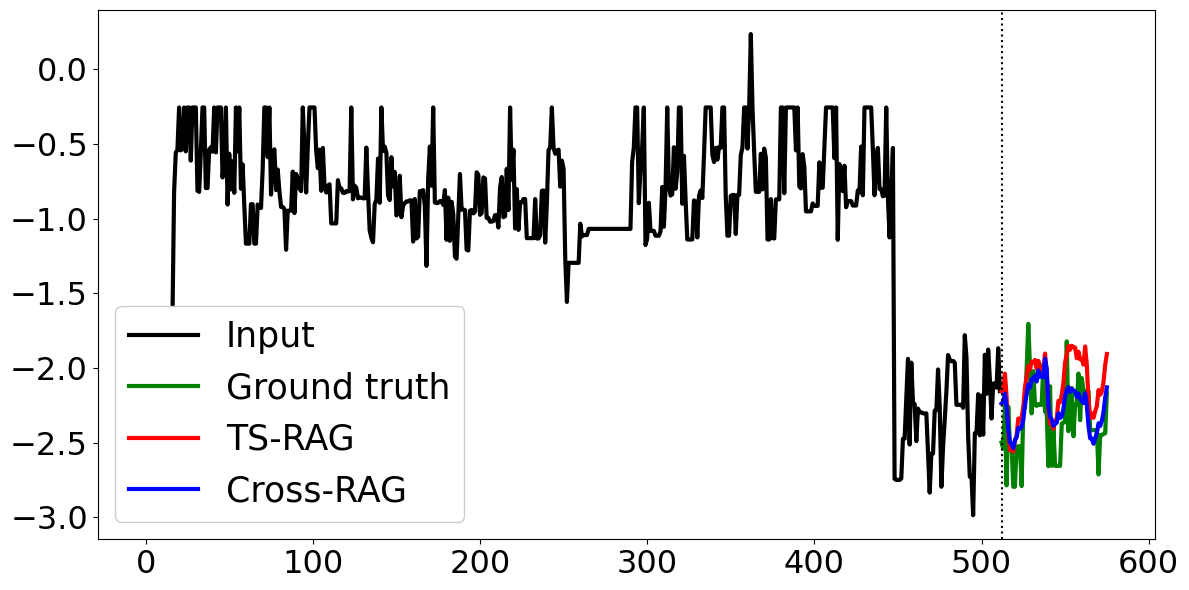

IndexError: list index out of range

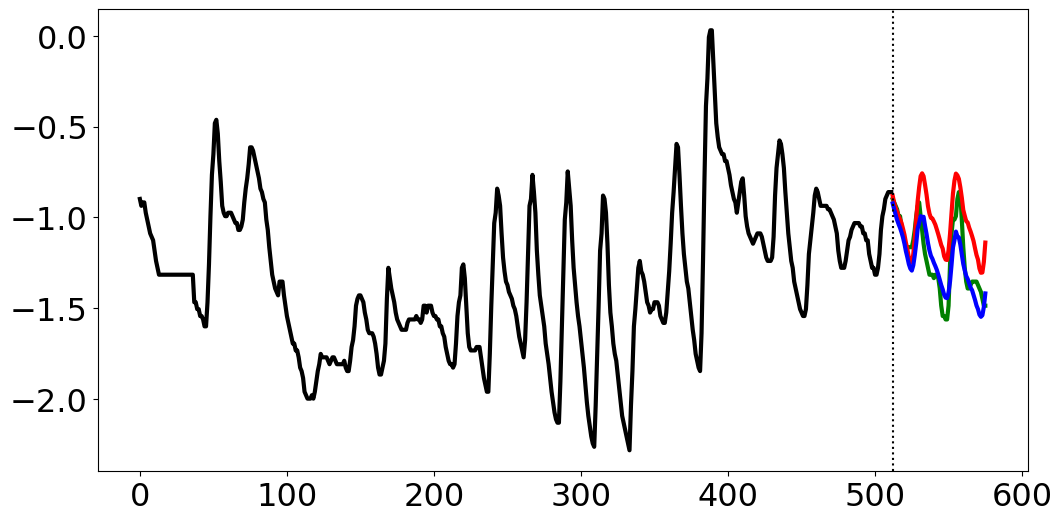

In [13]:
loc_list_dict = dict()
loc_list_dict['electricity'] = ['lower left','lower left','lower left','upper left','lower left','lower left',] # electricity
loc_list_dict['weather'] = ['upper left','upper left','upper left','upper left','lower left','lower left','upper left','lower left','upper left','upper left','upper left','upper left'] # weather
loc_list_dict['ETTm1'] = ['lower left','lower left','upper left','upper left','upper left','upper left','upper left','upper left'] # ETTm1
loc_list_dict['ETTm2'] = ['lower left','upper left','lower left','upper left','lower left','lower left','lower left','lower left','lower left','lower left','lower left','upper left'] # ETTm2
loc_list_dict['exchange'] = ['lower left','lower left','lower left','lower left','lower left','lower left','lower left','lower left','lower left','lower left'] # Exchange
loc_list_dict['ETTh2'] = ['lower left','lower left','lower left','lower left','lower left'] # ETTh2
loc_list_dict['ETTh1'] = ['lower left','lower left','lower left','lower left','lower left','lower left','lower left'] # ETTh1

#loc_list = ['lower left','lower left','upper left','upper left','upper left','upper left','upper left','upper left'] # ETTm1
#loc_list = ['lower left','lower left','lower left','lower left','lower left'] # ETTh2
#loc_list = ['lower left','lower left','lower left','lower left','lower left','lower left','lower left'] # ETTh1


for i, sample_idx in enumerate(index_list):
    plt.figure(figsize=(12, 6))
    plt.plot(np.arange(512), X[sample_idx], 'k-', linewidth=3, alpha=1.0, label='Input')
    plt.plot(np.arange(512, 512+64), Y_gt[sample_idx], 'g-', linewidth=3, label='Ground truth')
    plt.plot(np.arange(512, 512+64), Y_pred_base[sample_idx], 'red', linewidth=3, label=f'TS-RAG')
    plt.plot(np.arange(512, 512+64), Y_pred_ours[sample_idx], 'blue', linewidth=3, label=f'Cross-RAG')
    plt.axvline(x=512, color='black', linestyle=':', alpha=1.0)
#     plt.xticks(fontsize=15)
    plt.xticks(fontsize=23)
#     plt.yticks(fontsize=15)    
    plt.yticks(fontsize=23)    
#     plt.title(f'Sample {sample_idx}')
#     plt.legend(fontsize=20,loc=loc_list_dict[dataset][i])
    plt.legend(fontsize=25,loc=loc_list_dict[dataset][i], facecolor='white',    framealpha=1.0)
    #plt.grid(True, alpha=0.3)
    ########################################################################
    plt.tight_layout()
    SAVE_PATH = f'/home/seunghan.lee/workspace/experiments/figures/ts_viz/{dataset}'
    os.makedirs(SAVE_PATH,exist_ok=True)
    fn = f'{dataset}_{sample_idx}.pdf'
    fn = os.path.join(SAVE_PATH,fn)
    plt.savefig(fn, bbox_inches="tight")
    plt.show()


